<a href="https://colab.research.google.com/github/TheAllBlueChevy/UST-Deep-Learning-2026/blob/main/HWK_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0) Importing Libraries & Dataset

In [ ]:
# Import Libraries
import os
import pandas as pd
import kagglehub as kh
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Constant Variables
IMG_SIZE = 64
BATCH_SIZE = 128
LATENT_DIM = 32
ATTRIBUTES = ['Smiling', 'Eyeglasses', 'Male', 'Wearing_Hat', 'Young']

# Device check
print("TF version:", tf.__version__)

TF version: 2.20.0


In [ ]:
#Loading Dataset
path = kh.dataset_download("jessicali9530/celeba-dataset")
images_path = os.path.join(path, "img_align_celeba", "img_align_celeba")
celebs_path = os.path.join(path, "list_attr_celeba.csv")

attrs = pd.read_csv(celebs_path)
attrs = attrs[(attrs['Black_Hair'] == 1) | (attrs['Blond_Hair'] == 1)] # Filter for Black/Blonde Hair
attrs = attrs.sample(n=10000, random_state=42).reset_index(drop=True) # Random Sample of 10000
attrs = attrs[['image_id', 'Black_Hair', 'Blond_Hair'] + ATTRIBUTES]

# Train Test Split
train_df, test_df = train_test_split(attrs, test_size=0.2, random_state=42)

# 1) Data Preparation

In [ ]:
# Resize Image to 64 x 64 and Normalize
def preprocess(image_path, attr):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    # Data augmentation
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.cast(image, tf.float32) / 255.0
    return image, attr

def df_to_dataset(df, img_dir, shuffle=True):
    image_paths = [os.path.join(img_dir, fname) for fname in df['image_id']]
    attrs = df[ATTRIBUTES].values.astype('float32')

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, attrs))
    dataset = dataset.map(lambda x, y: preprocess(x, y), num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(df))
    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return dataset

# Build Datasets from Training and Testing DataFrames
train_ds = df_to_dataset(train_df, images_path)
test_ds = df_to_dataset(test_df, images_path, shuffle=False)

# 2) Encode Decode

In [ ]:
# Encoder
encoder_inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = layers.Conv2D(32, 4, strides=2, padding='same', activation='relu')(encoder_inputs)
x = layers.Conv2D(64, 4, strides=2, padding='same', activation='relu')(x)
x = layers.Conv2D(128, 4, strides=2, padding='same', activation='relu')(x)
x = layers.Conv2D(256, 4, strides=2, padding='same', activation='relu')(x)
x = layers.Flatten()(x)
mu = layers.Dense(LATENT_DIM)(x)
logvar = layers.Dense(LATENT_DIM)(x)

def sampling(args):
    mu, logvar = args
    epsilon = tf.random.normal(shape=tf.shape(mu))
    return mu + tf.exp(0.5 * logvar) * epsilon

z = layers.Lambda(sampling)([mu, logvar])
encoder = Model(encoder_inputs, [mu, logvar, z], name='encoder')
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 32, 32,    │      1,568 │ input_layer_8[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 16, 16,    │     32,832 │ conv2d_11[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 8, 8, 128) │    131,200 │ conv2d_12[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 4, 4, 256) │    524,544 │ conv2d_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 4096)      │          0 │ conv2d_14[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 32)        │    131,104 │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 32)        │    131,104 │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 32)        │          0 │ dense_10[0][0],   │
│                     │                   │            │ dense_11[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 952,352 (3.63 MB)

 Trainable params: 952,352 (3.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Decoder
latent_inputs = layers.Input(shape=(LATENT_DIM,))
attr_inputs = layers.Input(shape=(len(ATTRIBUTES),))

# Project attributes before concatenation
attr_proj = layers.Dense(LATENT_DIM, activation='relu')(attr_inputs)
x = layers.Concatenate()([latent_inputs, attr_proj])
x = layers.Dense(4*4*256, activation='relu')(x)
x = layers.Reshape((4,4,256))(x)
x = layers.Conv2DTranspose(128, 4, strides=2, padding='same', activation='relu')(x)
x = layers.Conv2DTranspose(64, 4, strides=2, padding='same', activation='relu')(x)
x = layers.Conv2DTranspose(32, 4, strides=2, padding='same', activation='relu')(x)
decoder_outputs = layers.Conv2DTranspose(3, 4, strides=2, padding='same', activation='sigmoid')(x)

decoder = Model([latent_inputs, attr_inputs], decoder_outputs, name='decoder')
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_9       │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 32)        │        192 │ input_layer_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 64)        │          0 │ input_layer_9[0]… │
│ (Concatenate)       │                   │            │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 4096)      │    266,240 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 4, 4, 256) │          0 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_12 │ (None, 8, 8, 128) │    524,416 │ reshape_3[0][0]   │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_13 │ (None, 16, 16,    │    131,136 │ conv2d_transpose… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_14 │ (None, 32, 32,    │     32,800 │ conv2d_transpose… │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_15 │ (None, 64, 64, 3) │      1,539 │ conv2d_transpose… │
│ (Conv2DTranspose)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 956,323 (3.65 MB)

 Trainable params: 956,323 (3.65 MB)

 Non-trainable params: 0 (0.00 B)

# 3) VAE

In [ ]:
class ConditionalVAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        x, attrs = data
        with tf.GradientTape() as tape:
            mu, logvar, z = self.encoder(x)
            x_recon = self.decoder([z, attrs])
            recon_loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(x, x_recon))
            recon_loss *= IMG_SIZE * IMG_SIZE * 3
            kl_loss = -0.5 * tf.reduce_mean(1 + logvar - tf.square(mu) - tf.exp(logvar))
            loss = recon_loss + kl_loss
        grads = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": loss}

vae = ConditionalVAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam(1e-3))
vae.fit(train_ds, epochs=30)  # increased epochs

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - loss: 0.0000e+00
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - loss: 0.0000e+00
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 0.0000e+00
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - loss: 0.0000e+00
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - loss: 0.0000e+00
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - loss: 0.0000e+00
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - loss: 0.0000e+00
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - loss: 0.0000e+00
Epoch 9/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - loss: 0.0000e+00
Epoch 10/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - loss: 0.0000e+00
Epoch 11/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - loss: 0.0000e+00
Epoch 12/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 0.0000e+00
Epoch 13/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 0.0000e+00
Epoch 14/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - loss: 0.0000e+00
Epoch 15/30
63/

# 5) Image Generation

In [ ]:
# Apply 1 Attribute Change
def apply_single_attribute(encoder, decoder, image, attr_vector, attr_index, alpha=1.0):
    """
    Modify one attribute for a given image.
    """
    attr_vector = attr_vector.copy()
    attr_vector[attr_index] = alpha
    mu, _, z = encoder(tf.expand_dims(image, 0))
    recon = decoder([z, tf.convert_to_tensor([attr_vector], dtype=tf.float32)])
    return recon[0]

In [ ]:
# Create Grid for Visualization of Attributes
def show_attribute_grid_with_original(sample_images, attr_names=ATTRIBUTES):
    nrows = len(sample_images)
    ncols = 1 + len(attr_names)  # First column = original
    plt.figure(figsize=(3*ncols, 3*nrows))

    for i, (img, attr_vec) in enumerate(sample_images):
        # Show original image
        plt.subplot(nrows, ncols, i*ncols + 1)
        plt.imshow(img)
        plt.title("Original")
        plt.axis('off')

        # Show modified images for each attribute
        for j, attr_name in enumerate(attr_names):
            mod_img = apply_single_attribute(encoder, decoder, img, attr_vec, j, alpha=1.0)
            plt.subplot(nrows, ncols, i*ncols + j + 2)
            plt.imshow(mod_img.numpy())
            plt.title(attr_name)
            plt.axis('off')

    plt.suptitle("Original Faces and Single Attributes Added")
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.6034666e-05..0.9231003].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.00029381714..0.9971834].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-8.874071e-05..0.99991125].


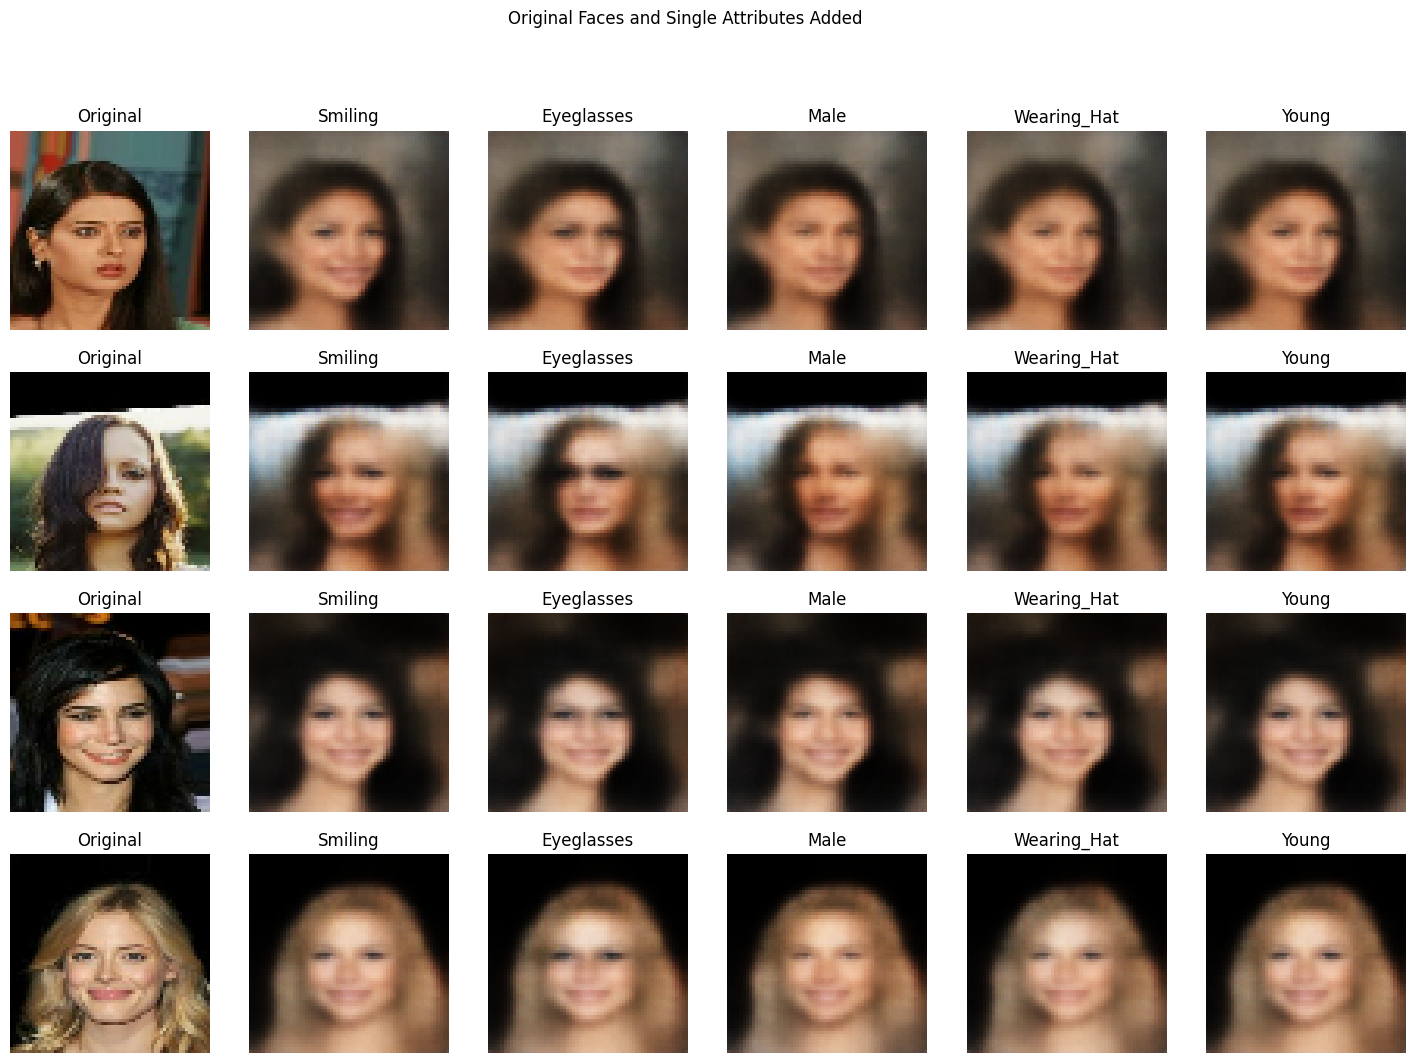

In [ ]:
# Randomly Sample 4 Faces
sample_images = []
for imgs, attrs in test_ds.shuffle(1000).take(1):
    for i in range(min(4, imgs.shape[0])):
        sample_images.append((imgs[i].numpy(), attrs[i].numpy()))
    break

# Show Grid Original and Attributes
show_attribute_grid_with_original(sample_images, attr_names=ATTRIBUTES)